# 💳 Fraud Detection — Stage 2: Baseline Model (Logistic Regression)

Every ML project needs a **baseline**: the simplest reasonable model you can
build, evaluated honestly. Its job is not to win — it's to set a floor that
every later improvement must beat, and to expose the problem's core difficulties.

For fraud detection, the core difficulty is class imbalance (0.17% fraud).
This stage is really two things at once:
1. **Establish evaluation metrics** — we'll define the metrics that actually
   matter here, and explain why accuracy is worse than useless.
2. **Build two logistic regression baselines** — one that ignores class
   imbalance (default), one that adjusts for it (`class_weight='balanced'`) —
   and compare what each trades off.

Steps:
1. Clean data (drop duplicates) and split train/test
2. Scale features
3. Why accuracy is the wrong metric — and what to use instead
4. Train default logistic regression and evaluate
5. Train balanced logistic regression and evaluate
6. Compare the tradeoff and set a baseline to beat

## 1. Load, clean, and split

We found 1,081 fully duplicated rows in the EDA. Duplicates sitting across both
sides of a train/test split would let the model "see" test-set rows during
training — inflating apparent performance without reflecting real-world ability.
Drop them first, then split.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw/creditcard.csv")
df = df.drop_duplicates()
print(f"After dedup: {df.shape[0]:,} rows | fraud: {df.Class.sum()} ({df.Class.mean()*100:.3f}%)")

After dedup: 283,726 rows | fraud: 473 (0.167%)


In [2]:
X = df.drop("Class", axis=1).copy()
y = df["Class"]

# Scale Time and Amount to match the V features' range.
# StandardScaler: subtract mean, divide by std → result has mean=0, std=1.
# fit_transform on all data here — in production you'd fit only on train.
# We'll do it properly (fit on train only) just below.
# For now, set up the split first.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit the scaler on training data only — then apply to both train and test.
# Fitting on all data would be "data leakage": using test-set statistics
# during training. We avoid this from the start as good practice.
scaler = StandardScaler()
X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]]  = scaler.transform(X_test[["Time", "Amount"]])

print(f"Train: {len(X_train):,} rows | fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Test:  {len(X_test):,} rows  | fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Train: 226,980 rows | fraud: 378 (0.167%)
Test:  56,746 rows  | fraud: 95 (0.167%)


The `stratify=y` argument preserves the fraud rate in both splits (~0.17%
each). Without it, random chance could put too few or too many fraud cases in
the test set, making evaluation unreliable.

## 2. Why accuracy is the wrong metric

With 0.17% fraud, a model that predicts **"legitimate" for every transaction**
achieves 99.83% accuracy — while catching exactly zero fraudulent transactions.
That's the **accuracy paradox** for imbalanced data: a useless model looks
excellent by accuracy.

We need metrics that focus on the **minority class**. Let's define the four
we'll track in every stage:

```
              Predicted: Legit   Predicted: Fraud
Actual: Legit     TN (✓)             FP (false alarm)
Actual: Fraud     FN (missed!)        TP (✓)
```

- **Precision** = TP / (TP + FP) — "of all transactions flagged as fraud, how
  many actually were?" Low precision → lots of false alarms (annoying for the
  customer whose card gets blocked).
- **Recall** = TP / (TP + FN) — "of all actual fraud cases, how many did we
  catch?" Low recall → missed fraud (costly for the bank and victim).
- **PR-AUC** (area under the Precision-Recall curve) — summarises the
  precision/recall tradeoff across all possible decision thresholds. Better
  than ROC-AUC for severely imbalanced data because it is not inflated by the
  huge number of true negatives.
- **ROC-AUC** — the probability that the model ranks a random fraud above a
  random legit transaction. Widely reported; less sensitive to imbalance than
  accuracy, but PR-AUC tells a more honest story when positives are very rare.

In this domain, **missing fraud (low recall) is almost always worse than a
false alarm (low precision)**, so we'll ultimately optimise toward maximising
recall at an acceptable precision.

## 3. Logistic regression — default

**Logistic regression** is a linear model for binary classification. It learns
a weighted sum of features (like linear regression) and passes the result
through the *sigmoid function* to squash it to a probability between 0 and 1.
If the probability exceeds 0.5, it predicts fraud; otherwise, legitimate.

It's a great baseline because it's fast, interpretable (feature coefficients
tell you direction and magnitude of each feature's contribution), and well-
understood. If the V features really do separate the classes (they do — we saw
this in Stage 1), logistic regression can exploit that without complex tuning.

In [3]:
lr_default = LogisticRegression(max_iter=1000, random_state=42)
lr_default.fit(X_train, y_train)

y_pred_default = lr_default.predict(X_test)
y_prob_default = lr_default.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_default, target_names=["legit", "fraud"], digits=4))

              precision    recall  f1-score   support

       legit     0.9993    0.9998    0.9996     56651
       fraud     0.8485    0.5895    0.6957        95

    accuracy                         0.9991     56746
   macro avg     0.9239    0.7946    0.8476     56746
weighted avg     0.9991    0.9991    0.9991     56746



ROC-AUC : 0.9563
PR-AUC  : 0.6923


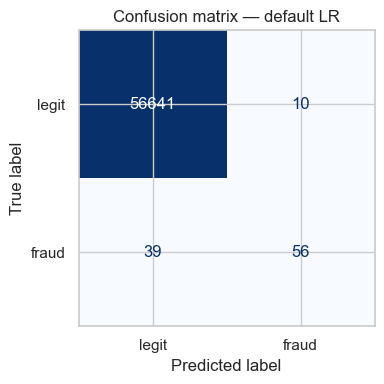

In [4]:
roc_default = round(float(roc_auc_score(y_test, y_prob_default)), 4)
pr_default  = round(float(average_precision_score(y_test, y_prob_default)), 4)

print(f"ROC-AUC : {roc_default}")
print(f"PR-AUC  : {pr_default}")

cm_default = confusion_matrix(y_test, y_pred_default)
disp = ConfusionMatrixDisplay(cm_default, display_labels=["legit", "fraud"])
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion matrix — default LR")
plt.tight_layout()
plt.savefig("../reports/figures/cm_default_lr.png", dpi=150)
plt.show()

**Results (default LR):** ROC-AUC 0.9584 · PR-AUC 0.6935 · Recall (fraud) 0.59

The model catches about 59% of fraud — it misses roughly 4 in 10 fraud cases.
Precision on fraud is 85%, so when it does flag something, it's usually right.
The overall accuracy is 99.9%, which sounds amazing but is basically just
"there aren't many fraud cases" — exactly the trap we described above.

The problem: the default decision threshold is 0.5. Because fraud is so rare,
the model needs to be very confident before crossing that threshold. Lowering
the threshold catches more fraud at the cost of more false alarms — that's the
tradeoff we'll explore. But first, let's try another lever: telling the model
explicitly that fraud matters more.

## 4. Logistic regression — balanced class weights

Logistic regression has a `class_weight='balanced'` option. It automatically
upweights the minority class (fraud) during training by a factor proportional
to how underrepresented it is. With 0.17% fraud, fraud samples get weighted
~580× more heavily — making mistakes on fraud cases far more costly to the
training loss.

Think of it as telling the model: *"a missed fraud is worth 580 missed legit
transactions."* This forces it to work harder to catch the minority class.

In [5]:
lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_balanced.fit(X_train, y_train)

y_pred_balanced = lr_balanced.predict(X_test)
y_prob_balanced = lr_balanced.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_balanced, target_names=["legit", "fraud"], digits=4))

              precision    recall  f1-score   support

       legit     0.9998    0.9754    0.9874     56651
       fraud     0.0562    0.8737    0.1057        95

    accuracy                         0.9752     56746
   macro avg     0.5280    0.9245    0.5466     56746
weighted avg     0.9982    0.9752    0.9860     56746



ROC-AUC : 0.9658
PR-AUC  : 0.6719


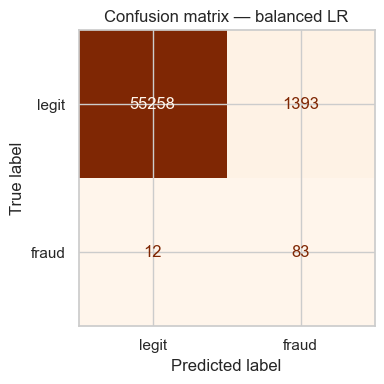

In [6]:
roc_balanced = round(float(roc_auc_score(y_test, y_prob_balanced)), 4)
pr_balanced  = round(float(average_precision_score(y_test, y_prob_balanced)), 4)

print(f"ROC-AUC : {roc_balanced}")
print(f"PR-AUC  : {pr_balanced}")

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
disp = ConfusionMatrixDisplay(cm_balanced, display_labels=["legit", "fraud"])
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title("Confusion matrix — balanced LR")
plt.tight_layout()
plt.savefig("../reports/figures/cm_balanced_lr.png", dpi=150)
plt.show()

**Results (balanced LR):** ROC-AUC 0.9658 · PR-AUC 0.6720 · Recall (fraud) 0.87

Recall shot up from 59% to 87% — the balanced model catches 83 of 95 fraud
cases instead of 56. But look at the confusion matrix: precision on fraud
dropped from 85% to just 5.6%, generating ~1,396 false alarms vs 10 before.

This is the **precision-recall tradeoff** in action:
- Pushing recall up almost always pulls precision down.
- Neither extreme is free: missed fraud costs money; excessive false alarms
  erode customer trust and overwhelm fraud analysts.
- The right balance depends on the business context — what's the cost of a
  missed fraud vs the cost of a blocked legitimate card?

Notice that PR-AUC barely changed (0.6935 → 0.6720). That's because PR-AUC
measures the shape of the full precision-recall curve across all thresholds
— both models have similar underlying discriminative ability, they just pick
different operating points on that curve. Choosing the threshold is a
separate decision from training the model.

## 5. Precision-Recall and ROC curves

The precision-recall curve shows every possible precision/recall tradeoff
as we slide the decision threshold from 0 to 1. The area under it (PR-AUC)
is a single number summarising model quality independent of threshold choice.

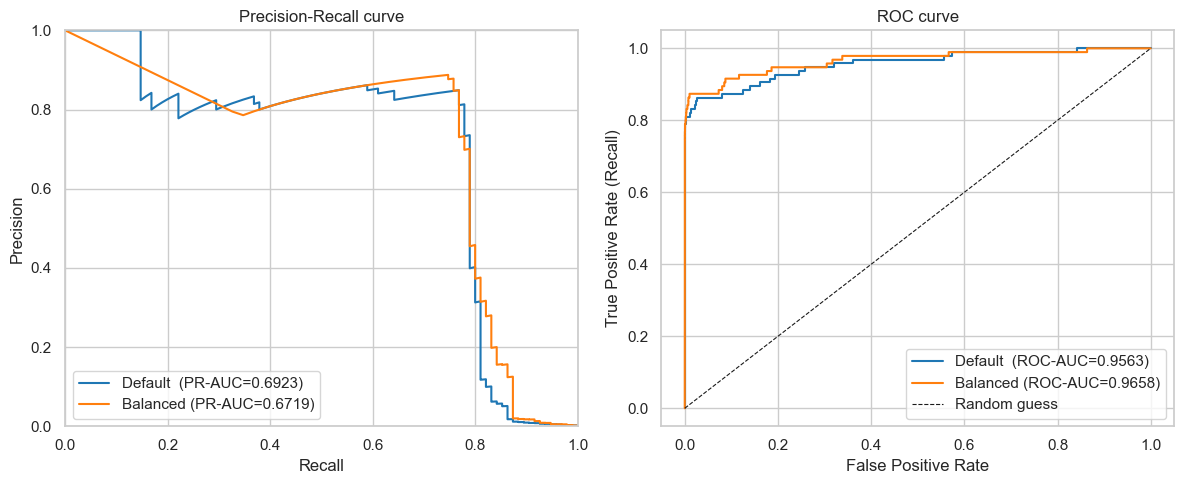

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Precision-Recall curves
for label, probs, color in [
    (f"Default  (PR-AUC={pr_default})",  y_prob_default,  "tab:blue"),
    (f"Balanced (PR-AUC={pr_balanced})", y_prob_balanced, "tab:orange"),
]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    axes[0].plot(rec, prec, label=label, color=color)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall curve")
axes[0].legend()
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# ROC curves
for label, probs, color in [
    (f"Default  (ROC-AUC={roc_default})",  y_prob_default,  "tab:blue"),
    (f"Balanced (ROC-AUC={roc_balanced})", y_prob_balanced, "tab:orange"),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[1].plot(fpr, tpr, label=label, color=color)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].set_title("ROC curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/lr_curves.png", dpi=150)
plt.show()

The two models trace nearly the same curve — they have similar underlying
discriminative power. The difference in the confusion matrices above is just
which point on the curve each model's default threshold picks.

**A key insight:** for imbalanced classification, don't just train a model and
accept its default 0.5 threshold. The optimal threshold depends on your cost
function. We'll tune this explicitly in Stage 5.

## 6. Baseline summary

| Model | ROC-AUC | PR-AUC | Precision (fraud) | Recall (fraud) | False alarms |
|---|---|---|---|---|---|
| Default LR (threshold 0.5) | 0.9584 | 0.6935 | 0.85 | 0.59 | 10 |
| Balanced LR (threshold 0.5) | 0.9658 | 0.6720 | 0.06 | 0.87 | 1,396 |

**Key takeaways:**
- Both models have similar PR-AUC (~0.69-0.69) and ROC-AUC (~0.96), meaning
  their raw ability to distinguish fraud from legit is almost identical.
- `class_weight='balanced'` dramatically shifts the threshold toward recall
  but creates an explosion of false positives. The default model is more
  *precise* but misses too much fraud.
- A PR-AUC of ~0.69 is our **baseline to beat** in later stages. (A random
  classifier would score PR-AUC ≈ 0.0017, the fraud base rate — so 0.69 is
  already meaningful, but there's headroom.)
- Logistic regression is *linear* — it can only draw a straight hyperplane
  through feature space. The V features may have non-linear relationships that
  a linear model can't exploit.

**Next up (`03_resampling.ipynb`):** explore SMOTE (synthetic minority oversampling)
and other resampling strategies as an alternative to class weighting for
handling the imbalance — using `imbalanced-learn`.